In [16]:
import ROOT
import numpy as np
import matplotlib.pyplot as plt
import os

In [17]:
Figure_Dir = "/Users/alexanderantonakis/Software/WireMod-Figures/XTxwStudies/"

In [18]:
DATA_DIR = "/Users/alexanderantonakis/WireProdGeomCut/"
os.system("ls "+DATA_DIR)

fd = DATA_DIR + "DATA_PROD_GEOM_CUT_XTXZQ_Full.root"
fm = DATA_DIR + "MC_PROD_GEOM_CUT_XTXZQ_Full.root"


fm = "/Users/alexanderantonakis/WireModHists/PROD/CALIB/MC_XTXZQ_CALIB_CRT2_Full.root"
fd = "/Users/alexanderantonakis/WireModHists/PROD/CALIB/DATA_CRT_XTXZQ_CALIB3_Full.root"

#f_binning = DATA_DIR+"binning_yz_500k.root"

rdata_file = ROOT.TFile.Open(fd, "READ")
rmc_file = ROOT.TFile.Open(fm, "READ")
#rbinning_file = ROOT.TFile.Open(f_binning, "READ")

rdata_file.ls()


DATA_PROD_GEOM_CUT_XTXZQ_Full.root
DATA_PROD_GEOM_CUT_XTXZW_Full.root
DATA_PROD_GEOM_CUT_YZQ_Full.root
DATA_PROD_GEOM_CUT_YZW_Full.root
MC_PROD_GEOM_CUT_XTXZQ_Full.root
MC_PROD_GEOM_CUT_XTXZW_Full.root
MC_PROD_GEOM_CUT_YZQ_Take3_Full.root
MC_PROD_GEOM_CUT_YZW_Full.root
binning_xtxz_500k.root
binning_yz_500k.root
splines_xtxzq_500k.root
splines_xtxzw_500k.root
splines_yzq_500k.root
splines_yzw_500k.root
TFile**		/Users/alexanderantonakis/WireModHists/PROD/CALIB/DATA_CRT_XTXZQ_CALIB3_Full.root	
 TFile*		/Users/alexanderantonakis/WireModHists/PROD/CALIB/DATA_CRT_XTXZQ_CALIB3_Full.root	
  KEY: THnSparseT<TArrayD>	hHit0;1	 projection  projection xtxzQ
  KEY: THnSparseT<TArrayD>	hTrack0;1	 projection  projection xtxzQ
  KEY: THnSparseT<TArrayD>	hHit1;1	 projection  projection xtxzQ
  KEY: THnSparseT<TArrayD>	hTrack1;1	 projection  projection xtxzQ
  KEY: THnSparseT<TArrayD>	hHit2;1	 projection  projection xtxzQ
  KEY: THnSparseT<TArrayD>	hTrack2;1	 projection  projection xtxzQ
  KEY: THnSpar

In [19]:
def get_bin_centers(h):
    x = []
    for num in range(1, h.GetNbinsX()+1):
        x.append(h.GetBinCenter(num))
    return np.array(x)

def get_bin_content(h):
    x = []
    for num in range(1, h.GetNbinsX()+1):
        x.append(h.GetBinContent(num))
    return np.array(x)

def get_bin_width(h):
    dx = abs(h.GetBinCenter(2) - h.GetBinCenter(1))
    return dx


In [20]:
def root_th2d_to_plt_hist2d(th2d):
    # Get the bin edges and contents from the ROOT TH2D
    x_edges = [th2d.GetXaxis().GetBinLowEdge(i) for i in range(1, th2d.GetNbinsX() + 2)]
    y_edges = [th2d.GetYaxis().GetBinLowEdge(i) for i in range(1, th2d.GetNbinsY() + 2)]
    z_values = np.zeros((th2d.GetNbinsX(), th2d.GetNbinsY()))

    for i in range(1, th2d.GetNbinsX() + 1):
        for j in range(1, th2d.GetNbinsY() + 1):
            z_values[i-1, j-1] = th2d.GetBinContent(i, j)

    return np.array(x_edges), np.array(y_edges), np.array(z_values)

In [21]:
def plotYZ(isData, tpc, plane):
    h = 0
    idx = 3*tpc + plane
    if isData:
        h = rdata_file.Get("hTrack"+str(idx))
    else:
        h = rmc_file.Get("hTrack"+str(idx))
    hproj = h.Projection(1, 0)
    hproj.GetXaxis().SetTitle("Reconstructed X [cm]")
    hproj.GetYaxis().SetTitle("Reconstructed #theta_{xw} [degrees]")
    T = ""
    if isData:
        T = f"Data (v10_06_00_09): TPC {tpc}, Plane {plane}"
    else:
        T = f"MC (v10_06_00_09): TPC {tpc}, Plane {plane}"
    hproj.SetTitle(T)
    hproj.SetStats(0)
    return hproj


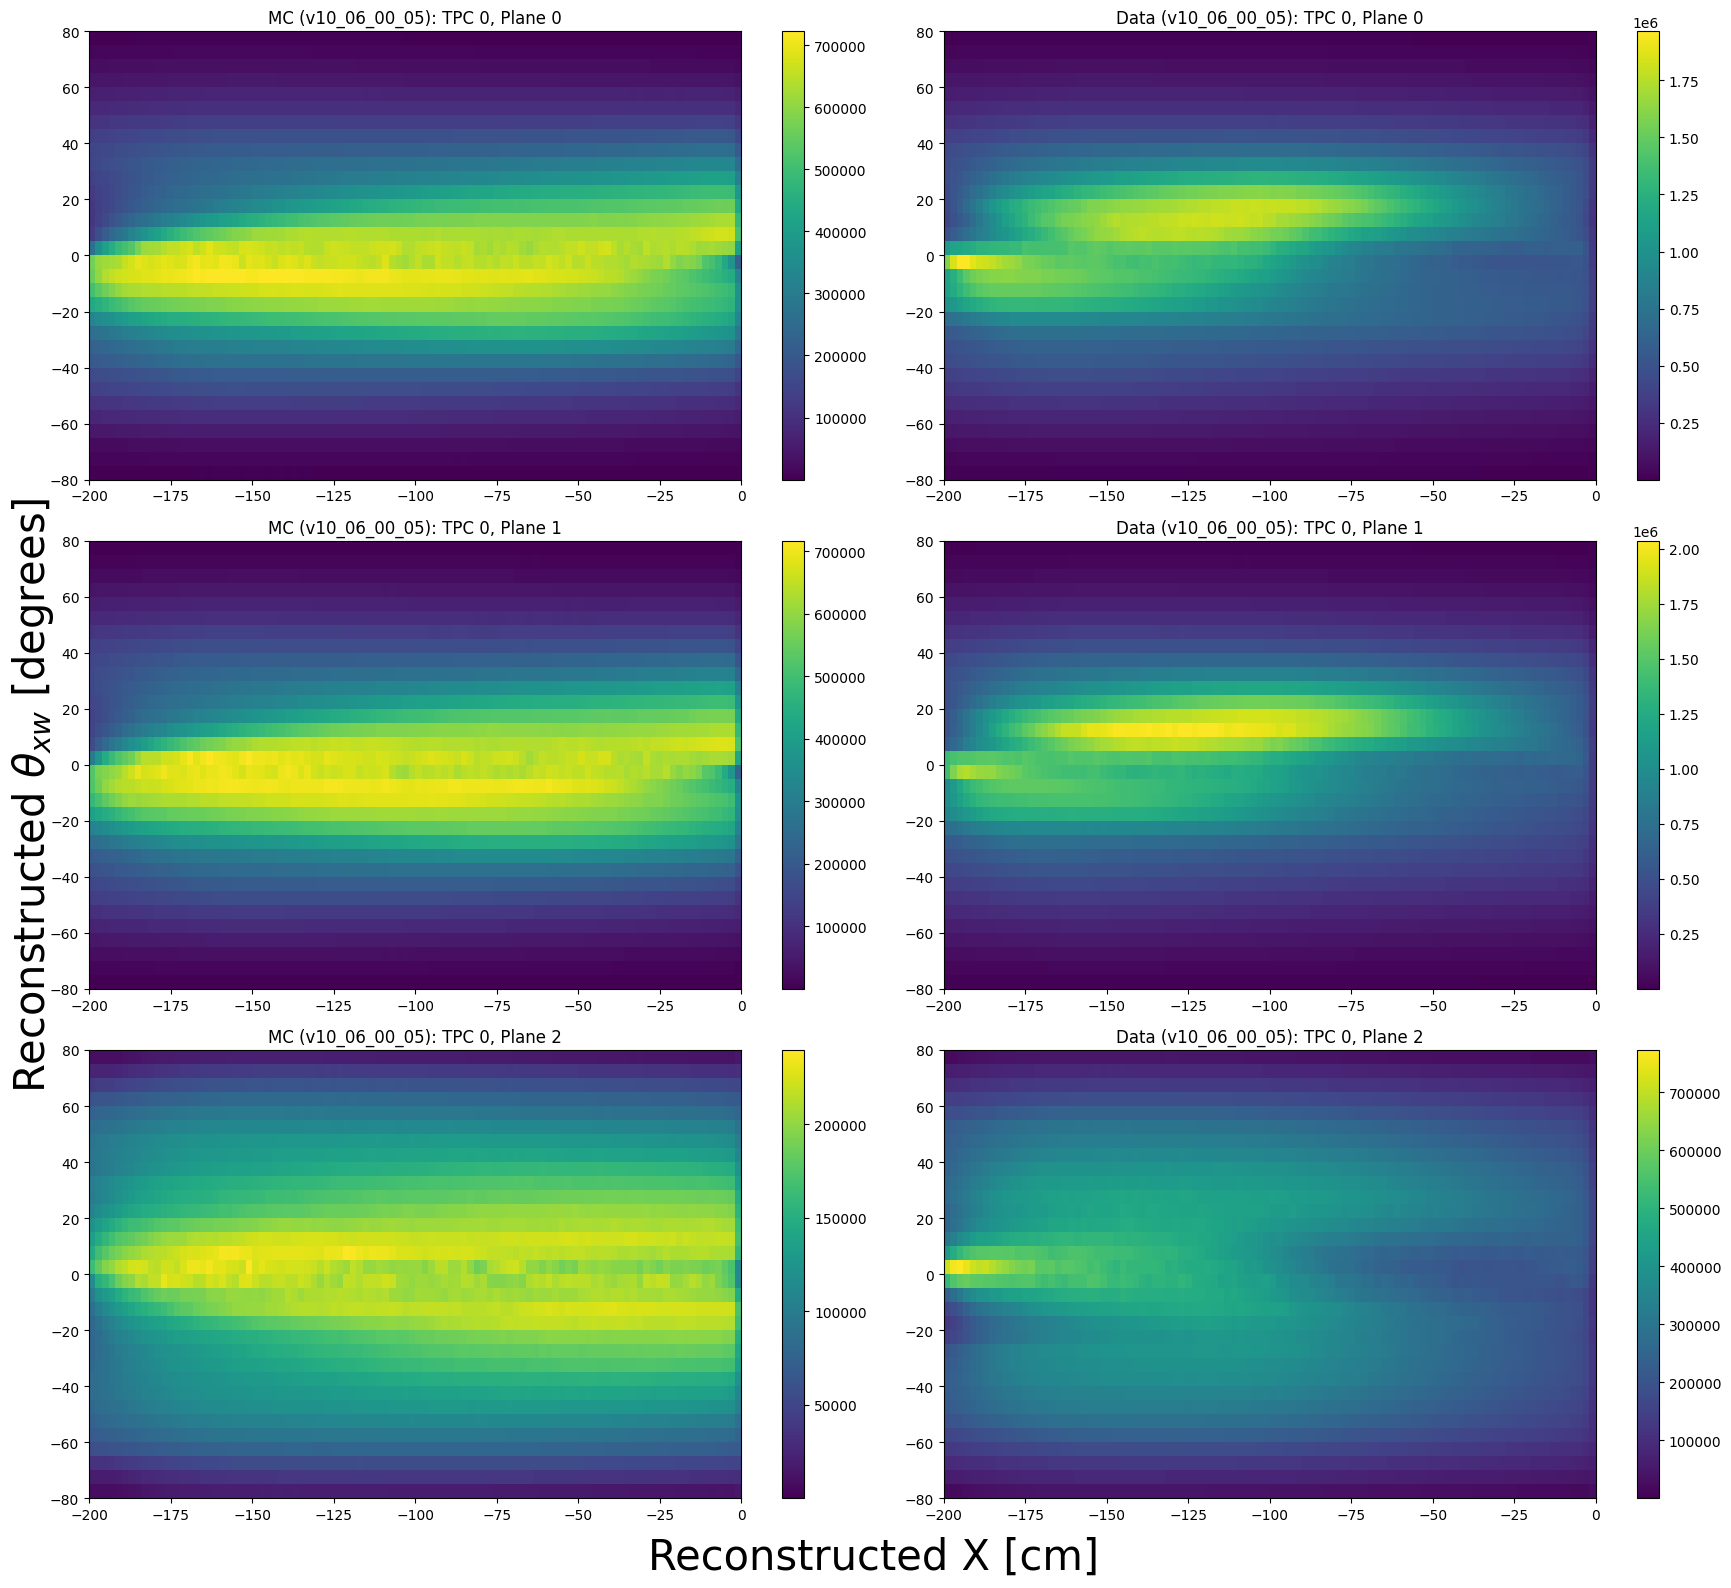

Warning in <TFile::Append>: Replacing existing TH1: hTrack0_proj_0_1 (Potential memory leak).
Warning in <TFile::Append>: Replacing existing TH1: hTrack1_proj_0_1 (Potential memory leak).
Warning in <TFile::Append>: Replacing existing TH1: hTrack2_proj_0_1 (Potential memory leak).


In [22]:
TPC = 0
fig, axes = plt.subplots(3, 2, figsize=(18, 16))
for plane in range(3):
    #idx = 3*TPC + plane

    #fig, axes = plt.subplots(3, 2, figsize=(18, 16))
    hmc = plotYZ(False, TPC, plane)
    hd = plotYZ(True, TPC, plane)

    # MC First
    x_edges, y_edges, z_values = root_th2d_to_plt_hist2d(hmc)
    z_masked = np.ma.masked_where(z_values == 0, z_values)
    cmap = plt.cm.viridis.copy()
    cmap.set_bad(color='white')

    X, Y = np.meshgrid(x_edges, y_edges, indexing='ij')  # Needed for pcolormesh
    #pcm = axs.pcolormesh(X, Y, z_masked, cmap=cmap, shading='auto', vmin=zlim[0], vmax=zlim[1])
    pcm = axes[plane][0].pcolormesh(X, Y, z_masked, cmap=cmap, rasterized=True, shading='auto')

    fig.colorbar(pcm, ax=axes[plane][0]) 
    axes[plane][0].set_title(f"MC (v10_06_00_05): TPC {TPC}, Plane {plane}")   
    axes[plane][0].set_xlim(-200, 0)
    axes[plane][0].set_ylim(-80, 80)  
    hmc.Delete()

    # Data Second
    x_edges, y_edges, z_values = root_th2d_to_plt_hist2d(hd)
    z_masked = np.ma.masked_where(z_values == 0, z_values)
    cmap = plt.cm.viridis.copy()
    cmap.set_bad(color='white')

    X, Y = np.meshgrid(x_edges, y_edges, indexing='ij')  # Needed for pcolormesh
    #pcm = axs.pcolormesh(X, Y, z_masked, cmap=cmap, shading='auto', vmin=zlim[0], vmax=zlim[1])
    pcm = axes[plane][1].pcolormesh(X, Y, z_masked, cmap=cmap, rasterized=True, shading='auto')

    fig.colorbar(pcm, ax=axes[plane][1]) 
    axes[plane][1].set_title(f"Data (v10_06_00_05): TPC {TPC}, Plane {plane}")     
    axes[plane][1].set_xlim(-200, 0)
    axes[plane][1].set_ylim(-80, 80)
    hd.Delete()

fig.supxlabel("Reconstructed X [cm]", fontsize=30)
fig.supylabel(r'Reconstructed $\theta_{xw}$ [degrees]', fontsize=30)
plt.tight_layout()
plt.savefig(Figure_Dir + f"tracks_xtxw_east_tpc_v10_06_00_05.png", bbox_inches="tight")
plt.show()


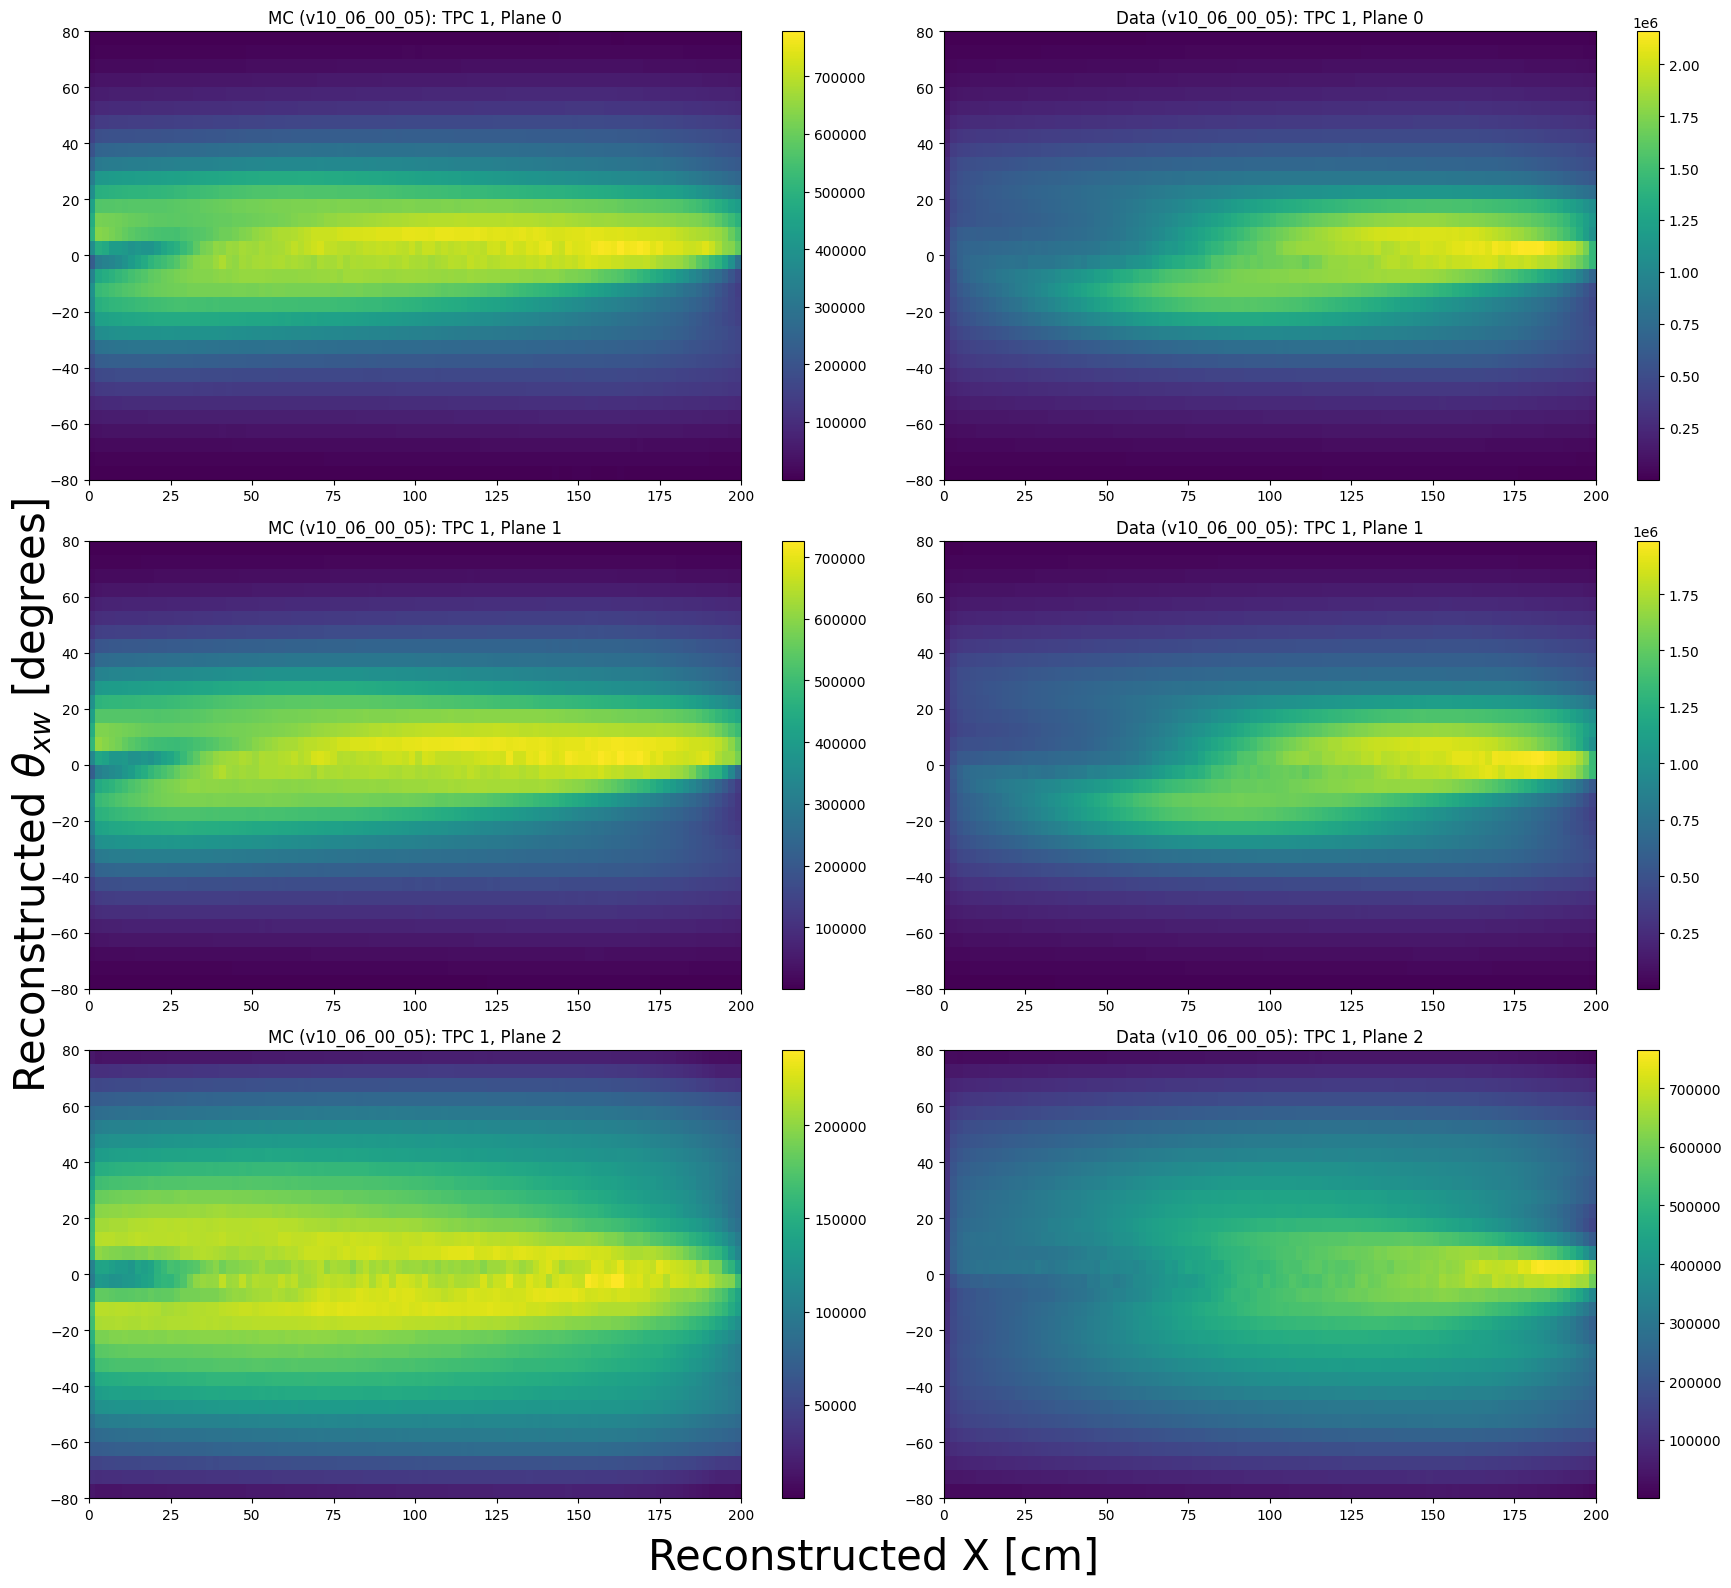

Warning in <TFile::Append>: Replacing existing TH1: hTrack3_proj_0_1 (Potential memory leak).
Warning in <TFile::Append>: Replacing existing TH1: hTrack4_proj_0_1 (Potential memory leak).
Warning in <TFile::Append>: Replacing existing TH1: hTrack5_proj_0_1 (Potential memory leak).


In [24]:
TPC = 1
fig, axes = plt.subplots(3, 2, figsize=(18, 16))
for plane in range(3):
    #idx = 3*TPC + plane

    #fig, axes = plt.subplots(3, 2, figsize=(18, 16))
    hmc = plotYZ(False, TPC, plane)
    hd = plotYZ(True, TPC, plane)

    # MC First
    x_edges, y_edges, z_values = root_th2d_to_plt_hist2d(hmc)
    z_masked = np.ma.masked_where(z_values == 0, z_values)
    cmap = plt.cm.viridis.copy()
    cmap.set_bad(color='white')

    X, Y = np.meshgrid(x_edges, y_edges, indexing='ij')  # Needed for pcolormesh
    #pcm = axs.pcolormesh(X, Y, z_masked, cmap=cmap, shading='auto', vmin=zlim[0], vmax=zlim[1])
    pcm = axes[plane][0].pcolormesh(X, Y, z_masked, cmap=cmap, rasterized=True, shading='auto')

    fig.colorbar(pcm, ax=axes[plane][0]) 
    axes[plane][0].set_title(f"MC (v10_06_00_05): TPC {TPC}, Plane {plane}")   
    axes[plane][0].set_xlim(0, 200)
    axes[plane][0].set_ylim(-80, 80)  
    hmc.Delete()

    # Data Second
    x_edges, y_edges, z_values = root_th2d_to_plt_hist2d(hd)
    z_masked = np.ma.masked_where(z_values == 0, z_values)
    cmap = plt.cm.viridis.copy()
    cmap.set_bad(color='white')

    X, Y = np.meshgrid(x_edges, y_edges, indexing='ij')  # Needed for pcolormesh
    #pcm = axs.pcolormesh(X, Y, z_masked, cmap=cmap, shading='auto', vmin=zlim[0], vmax=zlim[1])
    pcm = axes[plane][1].pcolormesh(X, Y, z_masked, cmap=cmap, rasterized=True, shading='auto')

    fig.colorbar(pcm, ax=axes[plane][1]) 
    axes[plane][1].set_title(f"Data (v10_06_00_05): TPC {TPC}, Plane {plane}")     
    axes[plane][1].set_xlim(0, 200)
    axes[plane][1].set_ylim(-80, 80)
    hd.Delete()

fig.supxlabel("Reconstructed X [cm]", fontsize=30)
fig.supylabel(r'Reconstructed $\theta_{xw}$ [degrees]', fontsize=30)
plt.tight_layout()
plt.savefig(Figure_Dir + f"tracks_xtxw_west_tpc_v10_06_00_05.png", bbox_inches="tight")
plt.show()
